##### The idea of this notebook is to intersect the genebody obtained from DeSeq2 to the chromatin loop anchors and make sense of the biological context of the project

In [ ]:
# date - 16.07.2025

In [1]:
import pandas as pd
from pybedtools import BedTool
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.formula.api import ols
from mygene import MyGeneInfo

In [2]:
# All the file loading
# Load genebody
genebody_up = BedTool("/usr/users/papantonis1/aman/rnaseq_data/upregulated_transcript_level_genebodies.bed")
genebody_down = BedTool("/usr/users/papantonis1/aman/rnaseq_data/downregulated_transcript_level_genebodies.bed")
# loops -mega ctrl + cpi
loops = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv", sep=",")
#loops_short = loops[['chr1', 'start1', 'end1', 'chr2', 'start2', 'end2']]
loops = pd.DataFrame(loops)
# splitting loops to their anchors
anchor1 = BedTool.from_dataframe(loops[['chr1', 'start1', 'end1']])
anchor2 = BedTool.from_dataframe(loops[['chr2', 'start2', 'end2']])

In [3]:
loops

,Unnamed: 0,chr1,start1,end1,chr2,start2,end2,status,ctrl_signal,rbp1_signal,...,H3K4me3_signal,rad21_signal,GC_mean,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2
0,0,chr1,1952500,1957500,chr1,2042500,2047500,shared,NaN,NaN,...,0.188543,0.024018,0.5773,0.0494,NaN,NaN,NaN,NaN,NaN,NaN
1,1,chr1,2202500,2207500,chr1,2382500,2387500,shared,NaN,NaN,...,0.566125,0.063427,0.6135,0.0578,NaN,NaN,NaN,NaN,NaN,NaN
2,2,chr1,2412500,2417500,chr1,2552500,2557500,shared,NaN,NaN,...,0.188543,0.044699,0.6525,0.0102,NaN,NaN,NaN,NaN,NaN,NaN
3,3,chr1,3490000,3495000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.024769,0.6002,0.0948,NaN,NaN,NaN,NaN,NaN,NaN
4,4,chr1,3565000,3570000,chr1,3615000,3620000,shared,NaN,NaN,...,0.188543,0.042592,0.5949,0.0842,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32272,32272,chrY,10945000,10950000,chrY,11290000,11295000,gained,0.006078,0.006342,...,0.188543,0.026824,0.4545,0.0226,-0.064836,-0.140925,0.270996,0.177009,-0.076090,-0.093987
32273,32273,chrY,10982500,10987500,chrY,11292500,11297500,gained,0.007661,0.005159,...,0.249019,0.130330,0.4609,0.0026,0.120802,-0.100746,0.270996,0.177009,-0.221548,-0.093987
32274,32274,chrY,11292500,11297500,chrY,11722500,11727500,gained,0.001017,0.001021,...,0.241160,0.123878,0.4195,0.0854,0.270996,0.177009,0.409095,0.332632,-0.093987,-0.076464
32275,32275,chrY,11530000,11535000,chrY,11760000,11765000,gained,0.004674,0.006621,...,0.214433,0.112741,0.3788,0.0120,-1.192141,-1.204536,-1.229772,-1.167283,-0.012394,0.062489


In [4]:
# to calculated real loop span for function below

# Read BEDPE file (assume first 6 columns: chrom1, start1, end1, chrom2, start2, end2, loop_id in col 6 or 7)
bedpe = pd.read_csv('/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/ml_5_multiclassmodel.csv', sep=',')

# For each row, get min(start1, start2) as loop_start, max(end1, end2) as loop_end
bedpe['loop_chr'] = bedpe['chr1']  # assuming intra-chromosomal
bedpe['loop_start'] = bedpe[['start1', 'start2']].min(axis=1) # The first anchor might not be leftmost, so we take the minimum of both anchor starts
bedpe['loop_end'] = bedpe[['end1', 'end2']].max(axis=1) # The second anchor might not be rightmost, so we take the maximum of both anchor ends.

# Now create BED DataFrame
loops_bed_df = bedpe[['loop_chr', 'loop_start', 'loop_end']]

# Convert to BedTool
loops_bed = BedTool.from_dataframe(loops_bed_df)

In [5]:
# Extend genebody regions for somewhat good intersection
genebody_up_slop = genebody_up.slop(b=500, genome='hg38')
genebody_down_slop = genebody_down.slop(b=500, genome='hg38')

In [6]:
genebody_df = genebody_up.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(genebody_df.duplicated().sum())  # total row duplicates
print(genebody_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [7]:
len(genebody_df)

2146

In [8]:
anchor_df = anchor1.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8228


In [9]:
anchor_df = anchor2.to_dataframe(names=["chrom", "start", "end"])
print(anchor_df.duplicated().sum())

8555


###### Here the duplicates are (possibly) due to the fact that same anchor can be shared by different distinct loops

In [10]:
genebody_df = genebody_down.to_dataframe(names=["chrom", "start", "end", "gene_id", "score", "strand"])
print(genebody_df.duplicated().sum())  # total row duplicates
print(genebody_df.duplicated(subset=["gene_id"]).sum())  # gene-level duplicates

0
0


In [11]:
# function1 # wa, wb - true. filt. later
# 1. Genes intersecting anchors (for both up and down)
def get_anchor_intersect(gene_bed, anchor_bed, deg_label, anchor_label):
    df = gene_bed.intersect(anchor_bed, wa=True, wb=True).to_dataframe(names=[
        'gene_chr', 'gene_start', 'gene_end', 'gene_id', 'gene_score', 'gene_strand',
        'anchor_chr', 'anchor_start', 'anchor_end'
    ])
    df['deg_class'] = deg_label
    df['region_label'] = anchor_label
    df['overlap_type'] = 'anchor_intersect'
    return df

# call the function in all combinations..
anchor_up_1 = get_anchor_intersect(genebody_up, anchor1, "upregulated", "anchor1")
anchor_up_2 = get_anchor_intersect(genebody_up, anchor2, "upregulated", "anchor2")
anchor_down_1 = get_anchor_intersect(genebody_down, anchor1, "downregulated", "anchor1")
anchor_down_2 = get_anchor_intersect(genebody_down, anchor2, "downregulated", "anchor2")

In [39]:
anchor_up_2

,gene_chr,gene_start,gene_end,gene_id,gene_score,gene_strand,anchor_chr,anchor_start,anchor_end,deg_class,region_label,overlap_type
0,chr1,22710838,22891265,ENST00000544305.5,0,+,chr1,22730000,22735000,upregulated,anchor2,anchor_intersect
1,chr1,22710838,22891265,ENST00000544305.5,0,+,chr1,22882500,22887500,upregulated,anchor2,anchor_intersect
2,chr1,22710838,22891265,ENST00000544305.5,0,+,chr1,22882500,22887500,upregulated,anchor2,anchor_intersect
3,chr1,22710838,22921500,ENST00000374630.8,0,+,chr1,22730000,22735000,upregulated,anchor2,anchor_intersect
4,chr1,22710838,22921500,ENST00000374630.8,0,+,chr1,22882500,22887500,upregulated,anchor2,anchor_intersect
...,...,...,...,...,...,...,...,...,...,...,...,...
1398,chrX,136665546,136767343,ENST00000370620.5,0,-,chrX,136692500,136697500,upregulated,anchor2,anchor_intersect
1399,chrX,136665546,136768627,ENST00000370622.5,0,-,chrX,136692500,136697500,upregulated,anchor2,anchor_intersect
1400,chrX,136665546,136768627,ENST00000370622.5,0,-,chrX,136692500,136697500,upregulated,anchor2,anchor_intersect
1401,chrX,136665549,136780932,ENST00000250617.7,0,-,chrX,136692500,136697500,upregulated,anchor2,anchor_intersect


In [12]:
# function2
# 2. Genes fully inside loops (for both up and down)
def get_loop_inside(gene_bed, loops_bed, deg_label):
    df = gene_bed.intersect(loops_bed, wa=True, wb=True).to_dataframe(names=[
        'gene_chr', 'gene_start', 'gene_end', 'gene_id', 'gene_score', 'gene_strand',
        'loop_chr', 'loop_start', 'loop_end', 'loop_id'
    ])
    df = df[(df['gene_start'] >= df['loop_start']) & (df['gene_end'] <= df['loop_end'])].copy()
    df['deg_class'] = deg_label
    df['region_label'] = df['loop_id']
    df['overlap_type'] = 'inside_loop'
    return df

# call the function in all combinations..
loop_up = get_loop_inside(genebody_up, loops_bed, "upregulated")
loop_down = get_loop_inside(genebody_down, loops_bed, "downregulated")

In [13]:
# Stack all as rows
master_df = pd.concat(
    [anchor_up_1, anchor_up_2, anchor_down_1, anchor_down_2, loop_up, loop_down],
    ignore_index=True
).drop_duplicates()
master_df

,gene_chr,gene_start,gene_end,gene_id,gene_score,gene_strand,anchor_chr,anchor_start,anchor_end,deg_class,region_label,overlap_type,loop_chr,loop_start,loop_end,loop_id
0,chr1,22710838,22891265,ENST00000544305.5,0,+,chr1,22762500.0,22767500.0,upregulated,anchor1,anchor_intersect,NaN,NaN,NaN,NaN
1,chr1,22710838,22921500,ENST00000374630.8,0,+,chr1,22762500.0,22767500.0,upregulated,anchor1,anchor_intersect,NaN,NaN,NaN,NaN
2,chr1,22710964,22921500,ENST00000400191.7,0,+,chr1,22762500.0,22767500.0,upregulated,anchor1,anchor_intersect,NaN,NaN,NaN,NaN
3,chr1,22710969,22914270,ENST00000374632.7,0,+,chr1,22762500.0,22767500.0,upregulated,anchor1,anchor_intersect,NaN,NaN,NaN,NaN
4,chr1,28369581,28459239,ENST00000633371.1,0,+,chr1,28402500.0,28407500.0,upregulated,anchor1,anchor_intersect,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10955,chr21,32377186,32377322,ENST00000363922.1,0,-,NaN,NaN,NaN,downregulated,NaN,inside_loop,chr21,31785000.0,32600000.0,NaN
10956,chr21,32377186,32377322,ENST00000363922.1,0,-,NaN,NaN,NaN,downregulated,NaN,inside_loop,chr21,32335000.0,32600000.0,NaN
10957,chr21,32377186,32377322,ENST00000363922.1,0,-,NaN,NaN,NaN,downregulated,NaN,inside_loop,chr21,31872500.0,32607500.0,NaN
10958,chr21,32377186,32377322,ENST00000363922.1,0,-,NaN,NaN,NaN,downregulated,NaN,inside_loop,chr21,32272500.0,32607500.0,NaN


In [14]:
# tss overlsp with anchor 1 & 2

In [15]:
# drop score, strand
#tss_anchors_updown.drop(["score", "strand"], axis=1)


#This is a check to make sure that my merged_loop list didn't have duplicates. big scare moment it was. But gave 0 duplicates--yay! I used this file for XGBoost model
cols = [
    "chr1", "start1", "end1",
    "chr2", "start2", "end2",
    "name", "score", "strand1", "strand2"
]  # adjust if fewer or more columns
df = pd.read_csv("/usr/users/papantonis1/aman/microc_project/loop_calling_premade_hic/jupyter_notes/merged_loops.csv", sep="\t", header=None, names=cols)
print(df.duplicated().sum())  # full row dupes
print(df.duplicated(subset=["chr1", "start1", "end1", "chr2", "start2", "end2"]).sum())  # loop duplicates

In [17]:
# next to deal with the non overlapping anchor at the distal end

In [18]:
# Match to left side of loop (chr1/start1/end1)
match_chr1 = master_df.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr1", "start1", "end1"],
    how="inner"
)
match_chr1["distal_chr"] = match_chr1["chr2"]
match_chr1["distal_start"] = match_chr1["start2"]
match_chr1["distal_end"] = match_chr1["end2"]

# Match to right side of loop (chr2/start2/end2)
match_chr2 = master_df.merge(
    loops,
    left_on=["anchor_chr", "anchor_start", "anchor_end"],
    right_on=["chr2", "start2", "end2"],
    how="inner"
)
match_chr2["distal_chr"] = match_chr2["chr1"]
match_chr2["distal_start"] = match_chr2["start1"]
match_chr2["distal_end"] = match_chr2["end1"]

# Combine both matches
final_matched_loops = pd.concat([match_chr1, match_chr2], ignore_index=True)

# Keep shortest loop per genebody-anchor to prevent duplicates
final_matched_loops = final_matched_loops.sort_values("distance").drop_duplicates(
    subset=["gene_id", "anchor_chr", "anchor_start", "anchor_end"],
    keep="first",
    ignore_index=True
)

# Output
final_matched_loops


,gene_chr,gene_start,gene_end,gene_id,gene_score,gene_strand,anchor_chr,anchor_start,anchor_end,deg_class,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end
0,chr16,69748747,69752253,ENST00000561677.6,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
1,chr16,69741870,69754926,ENST00000268802.10,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
2,chr16,69749309,69754917,ENST00000562416.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
3,chr16,69749052,69754792,ENST00000563055.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
4,chr16,69744902,69754914,ENST00000564620.5,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2542,chr4,113049548,113383725,ENST00000672045.1,0,+,chr4,113272500.0,113277500.0,upregulated,...,0.0016,0.797922,0.712603,0.532006,0.626927,-0.085318,0.094922,chr4,114682500,114687500
2543,chr9,83834098,83921432,ENST00000297814.7,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500
2544,chr9,83880117,83889270,ENST00000376347.1,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500
2545,chr9,83836697,83921465,ENST00000413982.5,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500


In [19]:
len(final_matched_loops)

2547

In [20]:
print(final_matched_loops.columns.tolist())


['gene_chr', 'gene_start', 'gene_end', 'gene_id', 'gene_score', 'gene_strand', 'anchor_chr', 'anchor_start', 'anchor_end', 'deg_class', 'region_label', 'overlap_type', 'loop_chr', 'loop_start', 'loop_end', 'loop_id_x', 'Unnamed: 0', 'chr1', 'start1', 'end1', 'chr2', 'start2', 'end2', 'status', 'ctrl_signal', 'rbp1_signal', 'log2FC', 'log2FC_clipped', 'condition', 'distance', 'loop_id_y', 'comp_switch_A1', 'comp_switch_A2', 'loop_class', 'source', 'CTCF_signal', 'H3K27me3_signal', 'H3K4me3_signal', 'rad21_signal', 'GC_mean', 'GC_diff', 'E1_anchor1_ctrl', 'E1_anchor1_rbp1', 'E1_anchor2_ctrl', 'E1_anchor2_rbp1', 'delta_E1_anchor1', 'delta_E1_anchor2', 'distal_chr', 'distal_start', 'distal_end']


In [21]:
# Show all rows
#pd.set_option('display.max_rows', None)

# Show all columns
#pd.set_option('display.max_columns', None)

# Now display
final_matched_loops[["gene_chr", "gene_start", "gene_end", "distal_chr", "distal_start", "distal_end"]]

,gene_chr,gene_start,gene_end,distal_chr,distal_start,distal_end
0,chr16,69748747,69752253,chr16,69715000,69720000
1,chr16,69741870,69754926,chr16,69715000,69720000
2,chr16,69749309,69754917,chr16,69715000,69720000
3,chr16,69749052,69754792,chr16,69715000,69720000
4,chr16,69744902,69754914,chr16,69715000,69720000
...,...,...,...,...,...,...
2542,chr4,113049548,113383725,chr4,114682500,114687500
2543,chr9,83834098,83921432,chr9,85842500,85847500
2544,chr9,83880117,83889270,chr9,85842500,85847500
2545,chr9,83836697,83921465,chr9,85842500,85847500


In [22]:
final_matched_loops

,gene_chr,gene_start,gene_end,gene_id,gene_score,gene_strand,anchor_chr,anchor_start,anchor_end,deg_class,...,GC_diff,E1_anchor1_ctrl,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end
0,chr16,69748747,69752253,ENST00000561677.6,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
1,chr16,69741870,69754926,ENST00000268802.10,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
2,chr16,69749309,69754917,ENST00000562416.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
3,chr16,69749052,69754792,ENST00000563055.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
4,chr16,69744902,69754914,ENST00000564620.5,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.0104,0.445361,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2542,chr4,113049548,113383725,ENST00000672045.1,0,+,chr4,113272500.0,113277500.0,upregulated,...,0.0016,0.797922,0.712603,0.532006,0.626927,-0.085318,0.094922,chr4,114682500,114687500
2543,chr9,83834098,83921432,ENST00000297814.7,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500
2544,chr9,83880117,83889270,ENST00000376347.1,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500
2545,chr9,83836697,83921465,ENST00000413982.5,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.0078,0.808115,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500


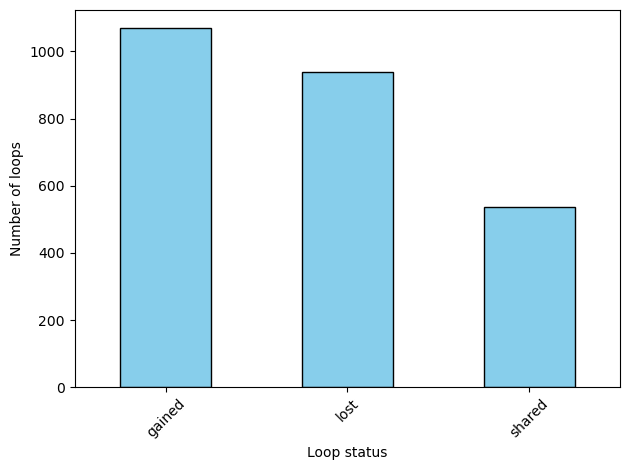

In [23]:
# Count the frequency of each status
status_counts = final_matched_loops['status'].value_counts()

# Plot
status_counts.plot(kind='bar', color='skyblue', edgecolor='black')
#plt.title('Loop Status Distribution')
plt.xlabel('Loop status')
plt.ylabel('Number of loops')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [24]:
# if TSS bed file have only 94 rows, how can it have more than 94 matched loops??

In [25]:
# Initialize
mg = MyGeneInfo()

# Strip version numbers from Ensembl transcript IDs
ensembl_tx_ids = final_matched_loops['gene_id'].dropna().str.replace(r'\.\d+$', '', regex=True).unique().tolist()

# Query gene symbols using cleaned transcript IDs
gene_info = mg.querymany(ensembl_tx_ids, scopes='ensembltranscript', fields='symbol', species='human')

# Convert to DataFrame and filter
gene_map_df = pd.DataFrame(gene_info)
if 'symbol' in gene_map_df.columns:
    gene_map_df = gene_map_df[['query', 'symbol']].dropna().drop_duplicates()
    gene_map_df.columns = ['gene_id', 'gene_symbol']

    # Merge with version-stripped IDs
    final_matched_loops['gene_id_novers'] = final_matched_loops['gene_id'].str.replace(r'\.\d+$', '', regex=True)
    final_matched_loops = final_matched_loops.merge(gene_map_df, left_on='gene_id_novers', right_on='gene_id', how='left')
    final_matched_loops.drop(columns=['gene_id_novers'], inplace=True)
    final_matched_loops.rename(columns={'gene_symbol': 'gene_symbol', 'query': 'gene_id'}, inplace=True)
else:
    print("No 'symbol' field found in MyGeneInfo results.")

Input sequence provided is already in string format. No operation performed
Input sequence provided is already in string format. No operation performed


In [26]:
# Show all rows
#pd.set_option('display.max_rows', None)

# Show all columns
#pd.set_option('display.max_columns', None)
final_matched_loops

,gene_chr,gene_start,gene_end,gene_id_x,gene_score,gene_strand,anchor_chr,anchor_start,anchor_end,deg_class,...,E1_anchor1_rbp1,E1_anchor2_ctrl,E1_anchor2_rbp1,delta_E1_anchor1,delta_E1_anchor2,distal_chr,distal_start,distal_end,gene_id_y,gene_symbol
0,chr16,69748747,69752253,ENST00000561677.6,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000561677,NOB1
1,chr16,69741870,69754926,ENST00000268802.10,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000268802,NOB1
2,chr16,69749309,69754917,ENST00000562416.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000562416,NOB1
3,chr16,69749052,69754792,ENST00000563055.1,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000563055,NOB1
4,chr16,69744902,69754914,ENST00000564620.5,0,-,chr16,69750000.0,69755000.0,upregulated,...,0.406969,0.163121,0.147383,-0.038392,-0.015738,chr16,69715000,69720000,ENST00000564620,NOB1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2542,chr4,113049548,113383725,ENST00000672045.1,0,+,chr4,113272500.0,113277500.0,upregulated,...,0.712603,0.532006,0.626927,-0.085318,0.094922,chr4,114682500,114687500,ENST00000672045,ANK2
2543,chr9,83834098,83921432,ENST00000297814.7,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500,ENST00000297814,KIF27
2544,chr9,83880117,83889270,ENST00000376347.1,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500,ENST00000376347,KIF27
2545,chr9,83836697,83921465,ENST00000413982.5,0,-,chr9,83882500.0,83887500.0,downregulated,...,0.916173,0.946126,0.936374,0.108057,-0.009752,chr9,85842500,85847500,ENST00000413982,KIF27


In [27]:
final_matched_loops.to_csv("merged_loops_with_genes.tsv", sep="\t", index=False)

In [28]:
genestocheck = final_matched_loops["gene_symbol"].dropna().unique().tolist()
genestocheck

['NOB1',
 'EDC3',
 'NSDHL',
 'LINC00880',
 'CEACAM5',
 'BAG3',
 'BHLHE40',
 'TUBB',
 'SCAF4',
 'HIP1',
 'TNS4',
 'TICAM1',
 'SP6',
 'GATAD2B',
 'SLC9A1',
 'MOB3A',
 'PHGDH',
 'CYP2S1',
 'PCBP1',
 'HEXIM1',
 'ZFP36L2',
 'LAMP3',
 'ZC3H4',
 'EGFR',
 'SMTN',
 'CKAP4',
 'EPHX1',
 'EPHB2',
 'BICC1',
 'GABPB2',
 'APLP2',
 'MUC13',
 'ALDH2',
 'SYT8',
 'PSAP',
 'LRRC45',
 'IL6R',
 'SEPTIN9',
 'CEMIP',
 'CAPN5',
 'FAM184B',
 'IGF1R',
 'CCNE2',
 'KIF27',
 'TBC1D16',
 'JPH2',
 'ATP2B4',
 'LGMN',
 'SH3PXD2B',
 'GALNT2',
 'SLC16A2',
 'CDCP1',
 'CLSTN1',
 'NR4A3',
 'PALM2AKAP2',
 'MTNR1A',
 'PDIA4',
 'ZNF185',
 'MMD',
 'PCK2',
 'SLC30A1',
 'HLA-B',
 'HLA-C',
 'LAMC2',
 'MDM1',
 'PHACTR4',
 'CEACAM19',
 'LDLR',
 'HRH1',
 'KCNQ1',
 'SYNPO',
 'PTPRF',
 'INSR',
 'PODXL',
 'LGALS3BP',
 'LSR',
 'TGFB1',
 'CKAP2L',
 'S100A11',
 'SIAE',
 'ATIC',
 'CDCA8',
 'CDH3',
 'ENPP1',
 'HLA-F',
 'SCPEP1',
 'SORT1',
 'ARHGEF38',
 'VAT1',
 'ECE1',
 'ARHGEF6',
 'SRPX',
 'CLU',
 'GAA',
 'APOBEC3B',
 'COL13A1',
 'NOTCH1',


In [29]:
len(genestocheck)

148

In [30]:
# to see if any genes have many transcripts
final_matched_loops["gene_symbol"].value_counts()

gene_symbol
ANK2          623
SEPTIN9        98
PALM2AKAP2     96
APLP2          75
IGF1R          67
             ... 
ALDH2           1
PSAP            1
HEXIM1          1
PMVK            1
GALNT2          1
Name: count, Length: 148, dtype: int64

In [31]:
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

In [32]:
# Fit linear model
model = ols('log2FC ~ C(status)', data=final_matched_loops).fit()

# Run ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                sum_sq      df          F        PR(>F)
C(status)   250.450987     2.0  89.942733  1.809474e-38
Residual   3541.961015  2544.0        NaN           NaN


---